In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import cvxpy as cvx
import riskfolio as rf

import statsmodels.api as sm

import scipy.stats as st
from scipy.linalg import expm, logm, sqrtm

import datetime as dt
from arch import arch_model

from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

In [2]:
# 1. Generate some artificial ARMA data (for demonstration)
np.random.seed(42)
nobs = 500
arparams = np.array([0.7, -0.2, 0.5, -0.1])  # AR coefficients
maparams = np.array([-0.4, -0.5, 0.8])        # MA coefficients

# Add a leading 1 for the AR and MA polynomial representation
arparams = np.r_[1, -arparams]
maparams = np.r_[1, maparams]

# Generate the ARMA time series
y = sm.tsa.arma_generate_sample(arparams, maparams, nobs, scale=1)

# Optionally, add dates for a pandas Series
dates = pd.date_range("1990-01-01", freq="H", periods=nobs)
y = pd.Series(y, index=dates)

In [3]:
np.mean(y)

np.float64(0.08803189608439523)

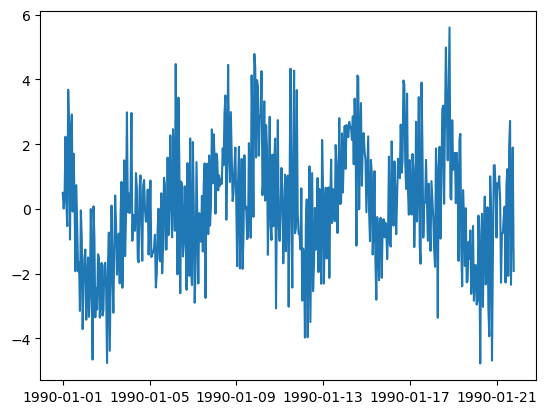

In [4]:
plt.plot(y)

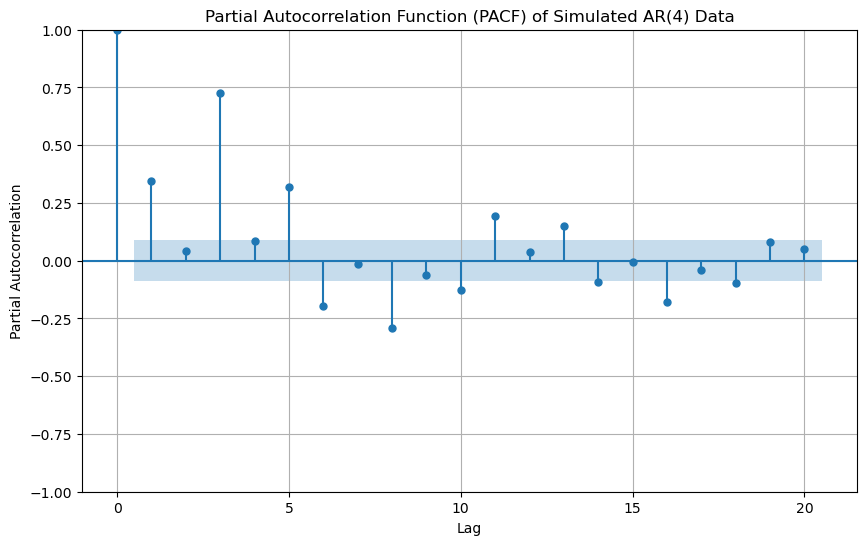

In [5]:
plt.figure(figsize=(10, 6))
plot_pacf(y, lags=20, method='ywm', ax=plt.gca()) # 'ywm' is a common method for PACF calculation
plt.title(f'Partial Autocorrelation Function (PACF) of Simulated AR({len(arparams)-1}) Data')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

In [6]:
# 2. Fit the ARMA model
# The order parameter is (p, q), where p is the AR order and q is the MA order.
# For an ARMA(2,1) model, the order would be (2, 1).
# We use ARIMA(y, order=(p, 0, q)) for ARMA models in statsmodels.
# 'trend="n"' indicates no constant term in the model.
arma_mod = sm.tsa.ARIMA(y, order=(len(arparams)-1, 0, 0), trend="n")
arma_res = arma_mod.fit()

# 3. Print the model summary
print(arma_res.summary())

# 4. Make predictions (optional)
# Predict the next 10 steps
forecast = arma_res.predict(start=len(y), end=len(y) + 9)
print("\nForecasted values:")
print(forecast)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  500
Model:                 ARIMA(4, 0, 0)   Log Likelihood                -800.795
Date:                Sat, 01 Nov 2025   AIC                           1611.590
Time:                        19:57:43   BIC                           1632.663
Sample:                    01-01-1990   HQIC                          1619.859
                         - 01-21-1990                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2400      0.046      5.216      0.000       0.150       0.330
ar.L2         -0.1844      0.036     -5.098      0.000      -0.255      -0.114
ar.L3          0.7019      0.032     21.797      0.0

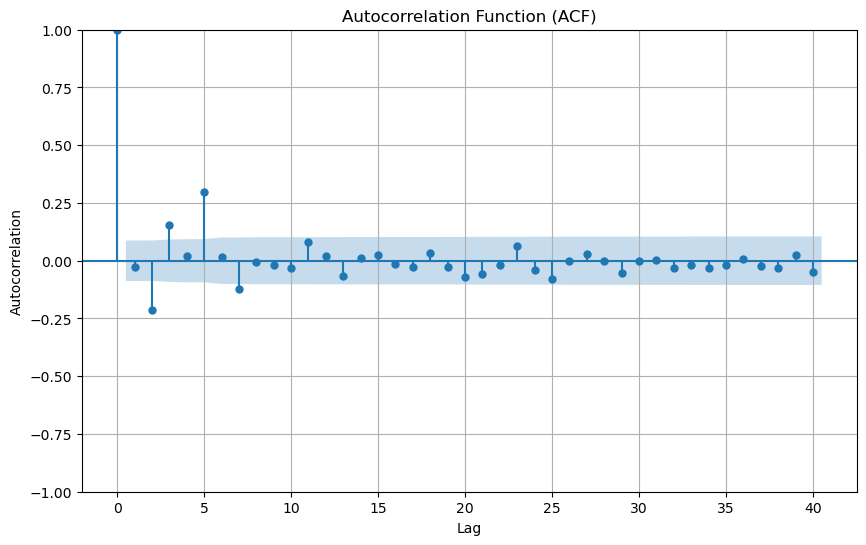

In [7]:
plt.figure(figsize=(10, 6))
plot_acf(arma_res.resid, lags=40, ax=plt.gca(), title='ACF of ARMA(1,1) Model Residuals')
plt.title(f'Autocorrelation Function (ACF)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 8000
Model:                 ARIMA(2, 2, 2)   Log Likelihood              -11490.367
Date:                Sat, 01 Nov 2025   AIC                          22990.733
Time:                        19:57:45   BIC                          23025.668
Sample:                             0   HQIC                         23002.691
                               - 8000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0124      0.011     -1.090      0.276      -0.035       0.010
ar.L2         -0.0030      0.011     -0.262      0.793      -0.025       0.019
ma.L1         -1.9973      0.001  -1460.053      0.0

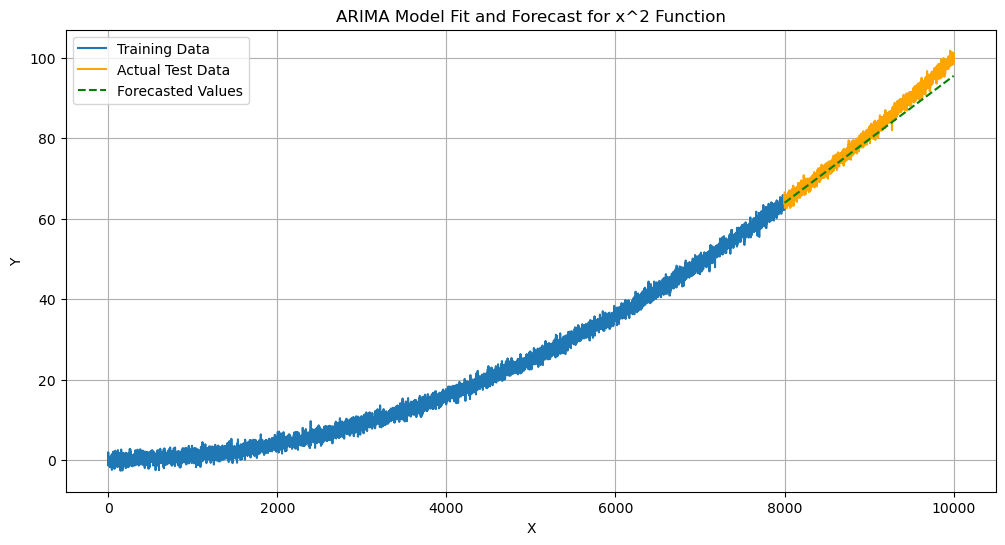

Root Mean Squared Error (RMSE) on test data: 2.27


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# 1. Generate the x^2 data
n_points = 10000
x = np.arange(n_points)
x_ = x/1000
y = x_**2 + np.random.normal(0, 1, n_points) # Add some noise for realism

# Create a Pandas Series for time series analysis
data = pd.Series(y, index=x)

# 2. Split data into training and testing sets
train_size = int(len(data) * 0.8)
train_data, test_data = data[0:train_size], data[train_size:]

# 3. Fit ARIMA model to the training data
# For a quadratic trend, a differencing order (d) of 2 might be suitable
# (x^2 -> 2x -> 2 -> 0). p and q can be determined by ACF/PACF plots
# or trial and error. Here, we'll use a simple (1,2,1) order as an example.
order = (2, 2, 2)
model = ARIMA(train_data, order=order)
model_fit = model.fit()

print(model_fit.summary())

# 4. Forecast values outside the model fit interval
forecast_steps = len(test_data)
forecast_start_index = len(train_data)
forecast_end_index = len(train_data) + forecast_steps - 1

forecast = model_fit.predict(start=forecast_start_index, end=forecast_end_index)

# 5. Plot the original data, fitted values, and forecasted values
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Actual Test Data', color='orange')
plt.plot(forecast.index, forecast, label='Forecasted Values', color='green', linestyle='--')
plt.title('ARIMA Model Fit and Forecast for x^2 Function')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

# 6. Evaluate forecasting accuracy
rmse = np.sqrt(mean_squared_error(test_data, forecast))
print(f"Root Mean Squared Error (RMSE) on test data: {rmse:.2f}")